# Observation–control alignment: `same_time` vs `previous_transition`

A controlled discrete-time model has to answer one bookkeeping question: **which
control does an observation see?** Dynestyx makes that choice explicit with the
`observation_control_alignment` argument to `DynamicalModel`.

**`"same_time"` (the default, and the historical behavior)** pairs $y_k$ with $u_k$:

$$
\begin{aligned}
x_0 &\sim p_0, \qquad & y_0 &\sim p(\cdot \mid x_0, u_0), \\
x_{k+1} &\sim p(\cdot \mid x_k, u_k), \qquad & y_k &\sim p(\cdot \mid x_k, u_k).
\end{aligned}
$$

Every prediction time carries one control and one observation, so `ctrl_values`
needs $T$ entries — even though only the first $T-1$ of them ever drive a
transition.

**`"previous_transition"`** instead pairs an observation with the control that
*produced* the state it is observing:

$$
\begin{aligned}
x_0 &\sim p_0, \\
x_{k+1} &\sim p(\cdot \mid x_k, u_k), \\
y_{k+1} &\sim p(\cdot \mid x_{k+1}, u_k).
\end{aligned}
$$

Now there is exactly one control per transition, so `ctrl_values` has $T-1$
entries — and $y_0$ is never sampled, because no control produced $x_0$.

This notebook runs both conventions on the same numbers so the difference is
visible rather than asserted.

In [10]:
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpy as np
import numpyro.distributions as dist

import dynestyx as dsx
from dynestyx import Filter
from dynestyx.inference.configs.filter import KFConfig
from dynestyx.models.observations import LinearGaussianObservation
from dynestyx.models.state_evolution import LinearGaussianStateEvolution

%matplotlib inline

## 1. A model whose observations reveal their control

To *see* the pairing rather than infer it from array shapes, we use a model where
both the transition and the observation are deterministic:

$$ x_{k+1} = x_k + u_k, \qquad y = x + 10\,u. $$

Because there is no noise anywhere, we can read the control back out of any
observation: $u = (y - x)/10$. The factor of $10$ just keeps the control term
clearly separated from the state term in the printouts.

The *only* difference between the two models below is the
`observation_control_alignment` argument.

In [11]:
def make_model(alignment):
    """1-D deterministic model whose observation encodes the control it was given."""

    def state_evolution(x, u, t_now, t_next):
        return dist.Delta(x + u).to_event(1)  # x_{k+1} = x_k + u_k

    def observation_model(x, u, t):
        return dist.Delta(x + 10.0 * u).to_event(1)  # y = x + 10 u

    return dsx.DynamicalModel(
        initial_condition=dist.Delta(jnp.array([0.0])).to_event(1),
        state_evolution=state_evolution,
        observation_model=observation_model,
        control_dim=1,
        observation_control_alignment=alignment,
    )


predict_times = jnp.arange(4.0)  # t = 0, 1, 2, 3  ->  T = 4
predict_times

Array([0., 1., 2., 3.], dtype=float32)

Two small helpers for reporting. `observation_table` decodes each observation to
recover the control it actually used, and reports which state that observation
belongs to. It works for both conventions by reading the offset straight off the
array lengths.

In [12]:
def summarize(result):
    for field in ("times", "states", "observations", "controls"):
        print(f"  {field:<13} {tuple(getattr(result, field).shape)}")


def observation_table(result):
    t = np.asarray(result.times[0])
    x = np.asarray(result.states[0, :, 0])
    y = np.asarray(result.observations[0, :, 0])
    u = np.asarray(result.controls[0, :, 0])

    offset = len(x) - len(y)  # 0 for same_time, 1 for previous_transition
    header = f"{'k':>3} {'controls[k]':>12} {'observed state':>18} {'obs[k]':>9} {'(y-x)/10':>10}"
    print(header)
    print("-" * len(header))
    for k in range(len(y)):
        x_k = x[k + offset]
        print(
            f"{k:>3} {u[k]:>12.1f} "
            f"{f'states[{k + offset}] @ t={t[k + offset]:.0f}':>18} "
            f"{y[k]:>9.1f} {(y[k] - x_k) / 10.0:>10.1f}"
        )

## 2. `same_time` (the default)

`ctrl_times` must be the full `predict_times` grid: one control per prediction
time.

In [13]:
model_same = make_model("same_time")
u_same = jnp.array([[1.0], [2.0], [3.0], [4.0]])  # T = 4 controls

result_same = dsx.simulate(
    model_same,
    rng_key=jr.PRNGKey(0),
    predict_times=predict_times,
    ctrl_times=predict_times,
    ctrl_values=u_same,
)

print("same_time shapes (n_simulations, time, dim):")
summarize(result_same)
print()
observation_table(result_same)

same_time shapes (n_simulations, time, dim):
  times         (1, 4)
  states        (1, 4, 1)
  observations  (1, 4, 1)
  controls      (1, 4, 1)

  k  controls[k]     observed state    obs[k]   (y-x)/10
--------------------------------------------------------
  0          1.0    states[0] @ t=0      10.0        1.0
  1          2.0    states[1] @ t=1      21.0        2.0
  2          3.0    states[2] @ t=2      33.0        3.0
  3          4.0    states[3] @ t=3      46.0        4.0


Every observation sits on the same index as its control and its state:
`observations[k]` observes `states[k]` and used `controls[k]`. Note that
`controls[3] = 4.0` never drives a transition — there is no $x_4$ — it exists
only so that $y_3$ has a control to see.

## 3. `previous_transition`

Now `ctrl_times` is `predict_times[:-1]`: one control per *transition*.

In [14]:
model_prev = make_model("previous_transition")
u_prev = jnp.array([[1.0], [2.0], [3.0]])  # T - 1 = 3 controls

result_prev = dsx.simulate(
    model_prev,
    rng_key=jr.PRNGKey(0),
    predict_times=predict_times,
    ctrl_times=predict_times[:-1],
    ctrl_values=u_prev,
)

print("previous_transition shapes (n_simulations, time, dim):")
summarize(result_prev)
print()
observation_table(result_prev)

previous_transition shapes (n_simulations, time, dim):
  times         (1, 4)
  states        (1, 4, 1)
  observations  (1, 3, 1)
  controls      (1, 3, 1)

  k  controls[k]     observed state    obs[k]   (y-x)/10
--------------------------------------------------------
  0          1.0    states[1] @ t=1      11.0        1.0
  1          2.0    states[2] @ t=2      23.0        2.0
  2          3.0    states[3] @ t=3      36.0        3.0


The states are identical to the `same_time` run — the same three controls drove
the same three transitions — but the observations shifted by one: `observations[0]`
now observes `states[1]` at $t=1$, using `controls[0]`. There is no observation at
$t=0$.

## 4. Side by side

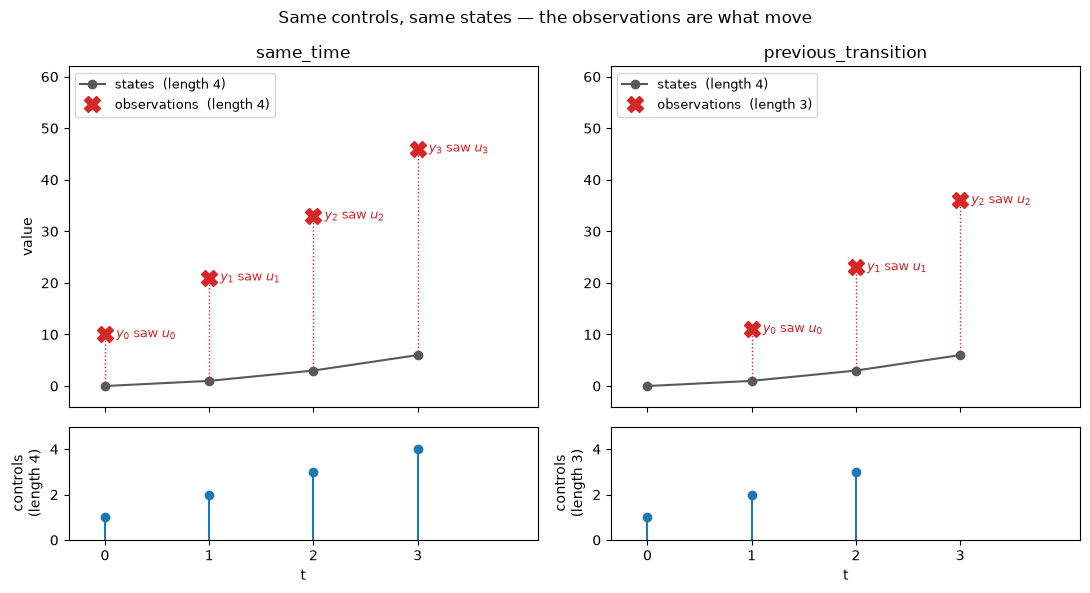

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(11, 6), sharex="col", height_ratios=[3, 1])

for col, (result, title) in enumerate(
    ((result_same, "same_time"), (result_prev, "previous_transition"))
):
    top, bottom = axes[0, col], axes[1, col]
    t = np.asarray(result.times[0])
    x = np.asarray(result.states[0, :, 0])
    y = np.asarray(result.observations[0, :, 0])
    u = np.asarray(result.controls[0, :, 0])
    offset = len(x) - len(y)

    top.plot(t, x, "o-", color="0.35", label=f"states  (length {len(x)})")
    top.plot(t[offset:], y, "X", ms=11, color="tab:red", label=f"observations  (length {len(y)})")
    for k in range(len(y)):
        # each observation attaches to the state directly below it
        top.plot([t[k + offset]] * 2, [x[k + offset], y[k]], ":", color="tab:red", lw=1)
        top.annotate(
            f"$y_{{{k}}}$ saw $u_{{{k}}}$",
            (t[k + offset], y[k]),
            textcoords="offset points",
            xytext=(8, -2),
            color="tab:red",
            fontsize=9,
        )
    top.set_title(title)
    top.set_ylim(-4, 62)
    top.set_ylabel("value" if col == 0 else "")
    top.legend(loc="upper left", fontsize=9)

    # controls live at the first len(u) prediction times under both conventions
    bottom.stem(t[: len(u)], u, basefmt=" ", linefmt="tab:blue", markerfmt="o")
    bottom.set_ylim(0, 5)
    bottom.set_xticks(np.asarray(predict_times))
    bottom.set_xlabel("t")
    bottom.set_xlim(-0.35, 4.15)
    bottom.set_ylabel(f"controls\n(length {len(u)})")

fig.suptitle("Same controls, same states \u2014 the observations are what move")
fig.tight_layout()
plt.show()

## 5. What changes for you

| | `same_time` | `previous_transition` |
|---|---|---|
| `ctrl_times` must equal | `predict_times` | `predict_times[:-1]` |
| `result.times`, `result.states` | length $T$ | length $T$ |
| `result.observations`, `result.controls` | length $T$ | length $T-1$ |
| `observations[k]` observes | `states[k]` | `states[k+1]` |
| `observations[k]` used control | `controls[k]` | `controls[k]` |

Three things worth committing to memory:

1. **`x_0` is always returned, under both conventions.** `result.states` and
   `result.times` always have length $T$ and always line up with `predict_times`,
   so anything that plots states against times is convention-independent. The
   price is that under `previous_transition` `states` is one element *longer*
   than `observations` — `states[k+1]` pairs with `observations[k]`, not
   `states[k]`.
2. **`observations[k]` always pairs with `controls[k]`.** The offset is only ever
   against `states`/`times`, never between observations and controls.
3. **`result.controls` is new for both conventions.** The aligned controls now come
   back with the result (and are registered as a `<name>_controls` deterministic
   site), which saves threading them through by hand in receding-horizon code.

In [16]:
print("states  ", np.asarray(result_prev.states[0, :, 0]))
print("controls", np.asarray(result_prev.controls[0, :, 0]))
print("x_0     ", np.asarray(result_prev.x_0[0]), "  (also states[0])")

states   [0. 1. 3. 6.]
controls [1. 2. 3.]
x_0      [0.]   (also states[0])


## 6. Why $y_0$ is not sampled

It is tempting to ask for $y_0 \sim p(\cdot \mid x_0, u{=}\texttt{None})$ so that
`observations` stays length $T$. That is not available in general: an observation
model that genuinely depends on the control cannot be evaluated without one, and
under `previous_transition` there is no control that produced $x_0$.

In [17]:
try:
    model_prev.observation_model(x=jnp.array([0.0]), u=None, t=jnp.array(0.0))
except TypeError as err:
    print(f"{type(err).__name__}: {err}")

TypeError: unsupported operand type(s) for *: 'float' and 'NoneType'


So the shorter `observations` array is the cost of the convention, not an
oversight. If you need an observation at $t_0$, use `"same_time"`.

## 7. Filtering a `previous_transition` model raises

`previous_transition` is implemented for **generation only** — `dsx.simulate`,
`Simulator`, and `DiscreteTimeSimulator`. Every path that *conditions* on data
(Filter, Smoother, `LatentPathBuilder`) still assumes the `same_time` pairing, so
rather than silently scoring observations against the wrong controls, dynestyx
refuses.

To make the attempt realistic, here is a linear-Gaussian version of the same
system — a Kalman filter can actually run on this one. The observation keeps the
control feedthrough via `D`, so $y = Hx + 10u + \varepsilon$.

In [18]:
def make_lg_model(alignment):
    """Linear-Gaussian twin of the toy model, so a Kalman filter can run on it."""
    return dsx.DynamicalModel(
        initial_condition=dist.MultivariateNormal(jnp.array([0.0]), 0.1 * jnp.eye(1)),
        state_evolution=LinearGaussianStateEvolution(
            A=jnp.array([[0.9]]), B=jnp.array([[1.0]]), cov=0.05 * jnp.eye(1)
        ),
        observation_model=LinearGaussianObservation(
            H=jnp.eye(1), D=jnp.array([[10.0]]), R=0.2 * jnp.eye(1)
        ),
        control_dim=1,
        observation_control_alignment=alignment,
    )


filter_times = jnp.arange(8.0)  # T = 8
filter_u = jnp.linspace(1.0, 0.3, 8).reshape(-1, 1)

First generate a trajectory the usual way. Under `previous_transition` this gives
7 observations, sitting at `filter_times[1:]`, and the 7 controls that produced
them.

In [19]:
generated = dsx.simulate(
    make_lg_model("previous_transition"),
    rng_key=jr.PRNGKey(0),
    predict_times=filter_times,
    ctrl_times=filter_times[:-1],
    ctrl_values=filter_u[:-1],
)

obs_times = filter_times[1:]
obs_values = generated.observations[0]
ctrl_values = generated.controls[0]

print(f"observations {tuple(obs_values.shape)} at t = {np.asarray(obs_times)}")
print(f"controls     {tuple(ctrl_values.shape)}")

observations (7, 1) at t = [1. 2. 3. 4. 5. 6. 7.]
controls     (7, 1)


Now feed exactly that back into a Kalman filter — the natural next step, and the
one that fails:

In [20]:
try:
    with Filter(KFConfig()):
        dsx.condition(
            "f",
            make_lg_model("previous_transition"),
            obs_times=obs_times,
            obs_values=obs_values,
            ctrl_times=obs_times,
            ctrl_values=ctrl_values,
        )
except ValueError as err:
    print(f"{type(err).__name__}: {err}")

ValueError: observation_control_alignment='previous_transition' does not support obs_times-based conditioning yet (Filter/Smoother/LatentPathBuilder posterior rollout); only predict_times-only generation is supported. See issue #312.


The error arrives before any filtering happens — it is a guard on the convention,
not a numerical failure. It keys off `obs_times` alone, so it fires for *any*
attempt to condition, including on an uncontrolled model.

Nothing is wrong with the filter itself. The identical `KFConfig`, on the
`same_time` twin of the same system, runs and returns a marginal log-likelihood:

In [21]:
generated_same = dsx.simulate(
    make_lg_model("same_time"),
    rng_key=jr.PRNGKey(0),
    predict_times=filter_times,
    ctrl_times=filter_times,
    ctrl_values=filter_u,
)

with Filter(KFConfig()):
    conditioned = dsx.condition(
        "f",
        make_lg_model("same_time"),
        obs_times=filter_times,
        obs_values=generated_same.observations[0],
        ctrl_times=filter_times,
        ctrl_values=filter_u,
    )

print("same_time marginal log-likelihood:", conditioned.marginal_loglik)

same_time marginal log-likelihood: -13.633939


The only difference between the two calls is the `observation_control_alignment`
string handed to `DynamicalModel`.

## 8. What is and isn't wired up

| | `same_time` | `previous_transition` |
|---|---|---|
| `dsx.simulate` / `Simulator` / `DiscreteTimeSimulator` | supported | supported |
| Filter / Smoother / `LatentPathBuilder` | supported | raises `ValueError` |
| `DiscreteControlLoopSimulator` | runs, ignores the field | runs, ignores the field |

So a `previous_transition` model can be simulated but not yet fitted.

`DiscreteControlLoopSimulator` always uses the previous-transition convention,
independent of this field. The `u` handed to each observation is the control that
produced that state, and no uncontrolled $y_0$ is emitted. Closed-loop results
therefore contain $T$ states and beliefs but $T-1$ aligned observations and controls.